In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def load_data(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    try:        
        data = pd.read_csv(file_path)
        return data
    except Exception as e:
        raise IOError(f"Error reading the file: {e}") 
    

In [4]:
df_student = load_data('study_hours_marks.csv')
df_student.head()

,StudyHours,Marks
0,3.745401,10.252008
1,9.507143,17.091136
2,7.319939,20.200838
3,5.986585,18.019391
4,1.560186,6.699418


In [5]:
model = LinearRegression()
X = df_student[['StudyHours']]
y = df_student['Marks']
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
pred = model.predict(X)
print("Predictions:", pred)

Predictions: [ 9.947538   23.90597661 18.60724083 15.37704614  4.65362045  4.65303611
  2.28103919 21.85794886 15.43655816 18.02772009  1.37258278 24.37100932
 21.04071846  6.01804434  5.27880644  5.31707255  8.24449644 13.58668953
 11.33823336  7.92924005 15.69669491  4.25328991  7.95141922  9.74941049
 11.92268656 19.89563238  5.71121315 13.33178295 15.22578059  1.99921244
 15.59232795  5.00503136  2.44984601 23.86167271 24.26737456 20.45819542
  8.25349706  3.24011317 17.45018135 11.53706826  3.83040862 12.87009385
  1.70700016 22.90316481  7.14312432 16.9242153   8.42543695 13.47310775
 14.11854508  5.35219905 24.36313041 19.65232657 23.63427235 22.55205507
 15.35867053 23.2072949   3.01772721  5.62179666  1.96958095  8.75537802
 10.29002615  7.44762307 20.95095767  9.51663385  7.67984157 14.02129686
  4.28794202 20.30798486  2.67997072 24.78229743 19.58236036  5.68800213
  1.00768051 20.62933035 17.99827974 18.53488303 19.55875393  2.66771252
  9.55811862  3.68095372 21.78350892 1

In [11]:
# calculate MAE and MSE without using sklearn
mae = np.mean(np.abs(pred - y))
mse = np.mean((pred - y) ** 2)
rmse = np.sqrt(mse)
r2 = r2_score(y, pred)

print(f"Mean Absolute Error    : {mae:.2f}") 
print(f"Mean Squared Error     : {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-square               : {r2:.2f}")

Mean Absolute Error    : 3.94
Mean Squared Error     : 24.37
Root Mean Squared Error: 4.94
R-square               : 0.67


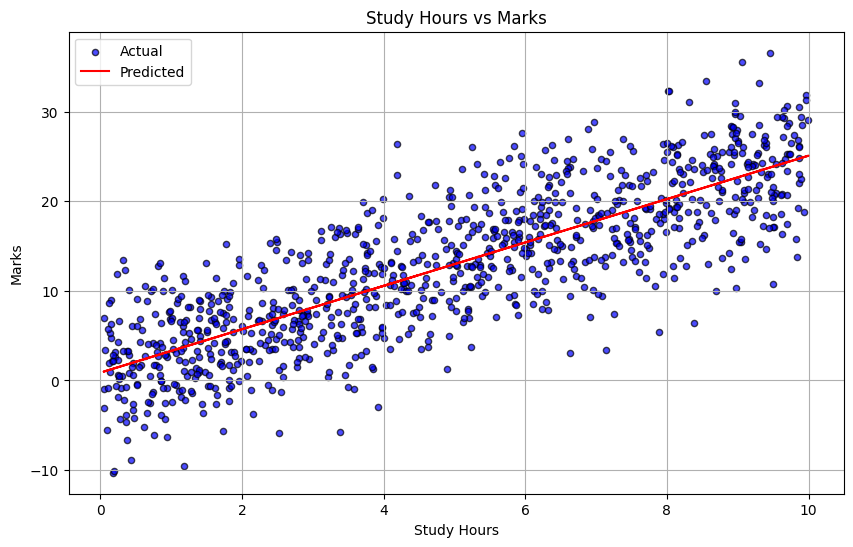

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='blue', label='Actual', s=20, alpha=0.7, edgecolors='black')

plt.plot(X, pred, color='red', label='Predicted')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Study Hours vs Marks')
plt.grid(True)
plt.legend()
plt.show()